# Environment setup and Google Drive mount
In this section, we connect Google Drive to access the MVTec dataset and set up a secure destination to save the results. We also install any missing dependencies.

In [1]:
from google.colab import drive
import os
import shutil
import glob

# Mount Google Drive
drive.mount('/content/drive')

!git clone -b contrastive_loss https://github.com/emanuelepietrocometti/sk-rd4ad.git
%cd /content/sk-rd4ad

!pip install --extra-index-url https://download.pytorch.org/whl/cu130 \
    torch>=2.1.0 torchvision>=0.16.0 numpy pandas scipy imageio matplotlib \
    opencv-python opencv-contrib-python Pillow scikit-image scikit-learn \
    fastprogress geomloss tqdm

Mounted at /content/drive
Cloning into 'sk-rd4ad'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 188 (delta 108), reused 73 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (188/188), 131.82 KiB | 1.09 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/sk-rd4ad


# Configuration variables (CURRENT RUN)
Set the dataset class you want to train and the name of the results folder for this iteration. Update these values for each new run.

In [3]:
# === CONFIGURE YOUR RUN HERE ===
CLASS_NAME = "reda_dustValidationAndTrain"
RUN_NAME = "13072026_221925_skrd4ad_reda_dustOnValidationAndTrain"

# Source and Destination Paths (Google Drive)
DRIVE_DATASET_PATH = f"/content/drive/MyDrive/Tesi/MVTec/{CLASS_NAME}"
DRIVE_DUST_BANK_PATH = "/content/drive/MyDrive/Tesi/MVTec/dust_bank"
DRIVE_RESULTS_PATH = f"/content/drive/MyDrive/Tesi/results/{RUN_NAME}"

# Local Paths (Fast Colab Storage)
LOCAL_DATASET_PATH = f"./mvtec/{CLASS_NAME}"
LOCAL_DUST_BANK_PATH = "./dust_bank"
LOCAL_CHECKPOINT_PATH = "./checkpoints"
LOCAL_IMG_PATH = "./results_maps"
LOCAL_VV_REPORT_PATH = "./vv_report"

# === DUST CONTRASTIVE LOSS (branch contrastive_loss) ===
USE_CONTRASTIVE = 1         # 0 = comportamento identico al baseline originale
CONTRASTIVE_RATE = 0.3       # lambda del termine contrastivo — DA VALIDARE con un'ablation
CONTRASTIVE_TEMP = 0.3       # temperatura della N-pair/InfoNCE loss — DA VALIDARE con un'ablation

# Local dataset preparation
Deep Learning frameworks are significantly slower when reading images directly from Google Drive. This cell copies the dataset to Colab's local memory to maximize training speed.

In [4]:
import shutil

print("Comprimo il dataset...")
shutil.make_archive(f"/content/drive/MyDrive/Tesi/MVTec/{CLASS_NAME}", 'zip', DRIVE_DATASET_PATH)
print("Comprimo il dust_bank...")
shutil.make_archive("/content/drive/MyDrive/Tesi/MVTec/dust_bank", 'zip', DRIVE_DUST_BANK_PATH)
print("Fatto. Da ora in poi la cella di preparazione dati copiera' solo questi due .zip.")

Comprimo il dataset...
Comprimo il dust_bank...
Fatto. Da ora in poi la cella di preparazione dati copiera' solo questi due .zip.


In [5]:
print(f"Copio gli archivi compressi da Drive...")

os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)
os.makedirs(LOCAL_DUST_BANK_PATH, exist_ok=True)

# Copia il singolo file .zip (un solo trasferimento, non migliaia) e lo estrae in locale
if not os.path.exists(os.path.join(LOCAL_DATASET_PATH, "train")):
    shutil.copy(f"/content/drive/MyDrive/Tesi/MVTec/{CLASS_NAME}.zip", "/content/dataset.zip")
    shutil.unpack_archive("/content/dataset.zip", LOCAL_DATASET_PATH)
    print("Dataset estratto.")
else:
    print("Dataset gia' presente in locale, salto la copia.")

if USE_CONTRASTIVE == 1:
    if not os.path.exists(os.path.join(LOCAL_DUST_BANK_PATH, "dust_images")):
        shutil.copy("/content/drive/MyDrive/Tesi/MVTec/dust_bank.zip", "/content/dust_bank.zip")
        shutil.unpack_archive("/content/dust_bank.zip", LOCAL_DUST_BANK_PATH)
        print("dust_bank estratto.")
    else:
        print("dust_bank gia' presente in locale, salto la copia.")

os.makedirs(LOCAL_CHECKPOINT_PATH, exist_ok=True)
os.makedirs(LOCAL_IMG_PATH, exist_ok=True)

Copio gli archivi compressi da Drive...
Dataset estratto.
dust_bank estratto.


# Verification & Validation (V&V) della pipeline dust/contrastive
Esegue `verify_dust_pipeline.py` PRIMA del training vero. Se qualcosa fallisce la cella si ferma qui — controlla sempre a occhio `preview_views.png` prima di procedere.

V&V pipeline dust contrastive loss

--- 1. Struttura cartelle ---
[OK] raw_images / dust_images / dust_masks presenti

--- 2. Allineamento dust_images <-> dust_masks ---
[OK] 38 coppie immagine/maschera allineate su 38 immagini totali

--- 3. Sanità delle maschere ---
  file corrotti/illeggibili : 0
  mismatch dimensioni img/mask : 0
  maschere vuote/troppo piccole : 0
  maschere quasi-tutto-frame (>90% area, sospette) : 0
[OK] 38 patch di polvere utilizzabili

--- 4. Caricamento DustBank ---
[DustBank] 38 patch di polvere reale caricate (0 file scartati per maschera mancante/vuota) da ./dust_bank
[OK] DustBank caricata con 38 patch

--- 5-6. Correttezza del compositing ---
[OK] [polvere] compositing corretto: 364 px modificati, 65172 px invariati, range valido
[OK] [difetto-patch] compositing corretto: 3906 px modificati, 61630 px invariati, range valido
[OK] [difetto-scar] compositing corretto: 614 px modificati, 64922 px invariati, range valido
[OK] Griglia di anteprima salvata in .

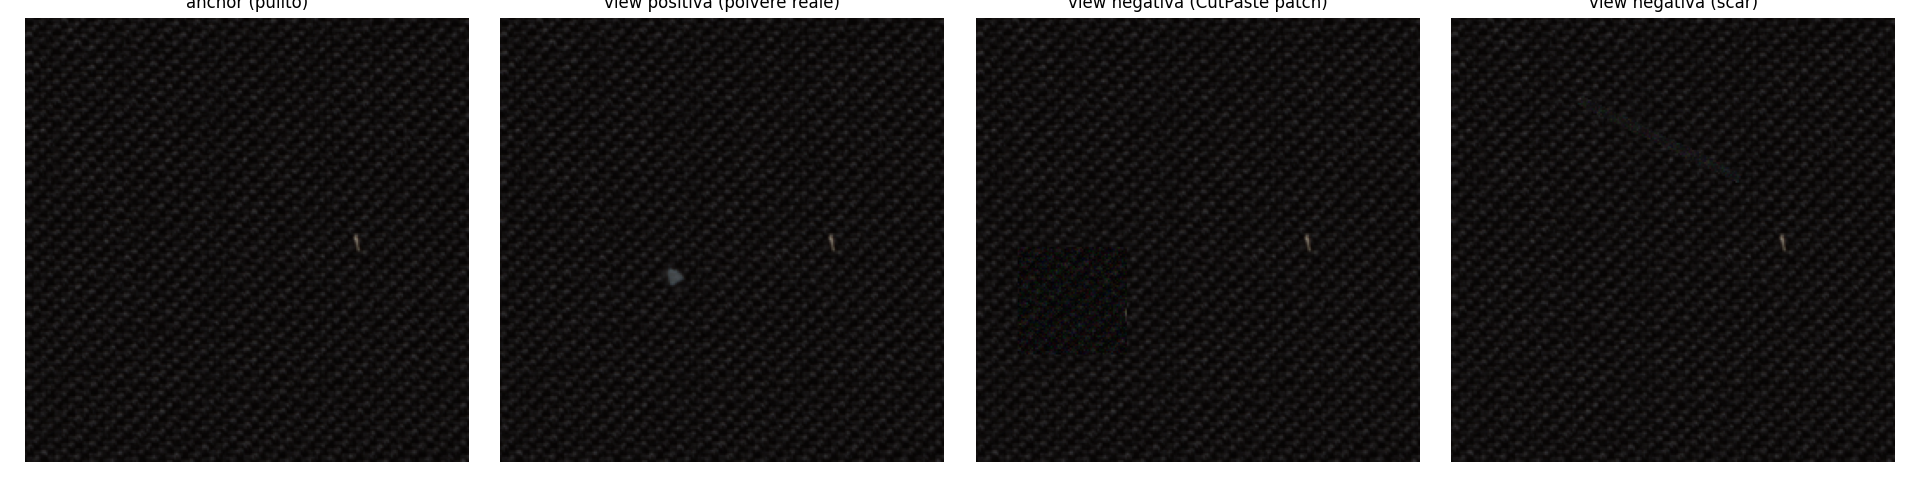

In [6]:
if USE_CONTRASTIVE == 1:
    !python verify_dust_pipeline.py \
      --dust_bank_path $LOCAL_DUST_BANK_PATH \
      --sample_image $(ls {LOCAL_DATASET_PATH}/train/good/*.bmp | head -n 1) \
      --out_dir $LOCAL_VV_REPORT_PATH

    from IPython.display import Image, display
    display(Image(filename=os.path.join(LOCAL_VV_REPORT_PATH, "preview_views.png")))
else:
    print("USE_CONTRASTIVE = 0: salto il V&V del dust_bank.")

# Training phase
Execute the `main.py` script. This will use the default parameters (e.g., 200 epochs, res=3, learning rate 0.005) applied to the selected class.

In [7]:
print(f"--- STARTING TRAINING FOR CLASS: {CLASS_NAME} (contrastive={USE_CONTRASTIVE}) ---")

!python main.py \
  --class_ $CLASS_NAME \
  --data_path ./mvtec/ \
  --save_path $LOCAL_CHECKPOINT_PATH/ \
  --img_path $LOCAL_IMG_PATH/ \
  --seed 42 \
  --L2 0 \
  --res 1 \
  --rate 0.5 \
  --batch_size 4 \
  --layerloss 0 \
  --seg 1 \
  --vis 0 \
  --print_epoch 20 \
  --learning_rate 0.0006 \
  --contrastive $USE_CONTRASTIVE \
  --contrastive_rate $CONTRASTIVE_RATE \
  --contrastive_temp $CONTRASTIVE_TEMP \
  --dust_bank_path $LOCAL_DUST_BANK_PATH

--- STARTING TRAINING FOR CLASS: reda_dustValidationAndTrain (contrastive=1) ---
--------args----------
epochs: 200
res: 1
learning_rate: 0.0006
batch_size: 4
seed: [42]
class_: reda_dustValidationAndTrain
seg: 1
print_epoch: 20
data_path: ./mvtec/
save_path: ./checkpoints/
print_canshu: 1
score_num: 1
print_loss: 1
img_path: ./results_maps/
vis: 0
cut: 0
layerloss: 0
rate: 0.5
print_max: 1
net: wide_res50
L2: 0
contrastive: 1
contrastive_rate: 0.3
contrastive_temp: 0.3
dust_bank_path: ./dust_bank
--------args----------

*************************
seed: 42
cuda
reda_dustValidationAndTrain
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth
100% 132M/132M [00:00<00:00, 230MB/s]
[DustBank] 38 patch di polvere reale caricate (0 file scartati per maschera mancante/vuota) da ./dust_bank
[contrastive] OCBE embedding channels = 2048, contrastive_rate = 0.3, contrastive_temp = 0.3
epoch [1/200], loss_

# Evaluation and metrics report
Run the `eval.py` script to generate the final report with AUPRO, AP-loc, F1-Score, etc., and save the heatmaps categorized by TP, TN, FP, FN.
The script automatically detects the latest generated checkpoint.

In [21]:
print(f"--- STARTING EVALUATION FOR CLASS: {CLASS_NAME} ---")

# Automatically locate the most recently generated .pth file in the local directory
checkpoints = glob.glob(f"{LOCAL_CHECKPOINT_PATH}/*.pth")

if not checkpoints:
    print("ERROR: No checkpoints found. The training phase might have failed.")
else:
    # Select the newest file if multiple exist
    latest_checkpoint = max(checkpoints, key=os.path.getctime)
    print(f"Using checkpoint: {latest_checkpoint}")

    # Create a specific subfolder for validation maps
    EVAL_IMG_PATH = os.path.join(LOCAL_IMG_PATH, "eval_report")
    os.makedirs(EVAL_IMG_PATH, exist_ok=True)

    !python eval.py \
      --class_ $CLASS_NAME \
      --data_path ./mvtec/ \
      --checkpoint_path $latest_checkpoint \
      --img_path $EVAL_IMG_PATH/ \
      --corner_size 8

--- STARTING EVALUATION FOR CLASS: reda_dustValidationAndTrain ---
Using checkpoint: ./checkpoints/wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.pth
Using device: cuda
Loading checkpoint from: ./checkpoints/wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.pth
Phase 1/2: Extracting anomaly scores and spatial maps...
Calculating pixel-level metrics (AUPRO, AP-loc, AUROC). This may take a moment...
 EVALUATION METRICS REPORT 
border_margin=0  corner_size=8  (ATTIVO)
--------------------------------------------------
--- SAMPLE LEVEL (Image Classification) ---
Optimal Threshold: 0.2822
AUROC:             0.9191
Accuracy:          0.9452
F1-Score:          0.9659
Precision:         0.9602
Recall:            0.9718
Confusion Matrix (TN, FP | FN, TP):
[[ 52  10]
 [  7 241]]

--- PIXEL LEVEL (Defect Localization) ---
AUPRO:             0.9324
AP-loc:            0.5358
Pixel AUROC:       0.9602
Calibration saved to ./results_maps/eval_report/calibration_pytorch.json

Phase 

# Hyperparameter Fine-Tuning (Optional)
Run this block only if you want to execute the hyperparameter grid search.

In [ ]:
print(f"--- STARTING HYPERPARAMETER TUNING FOR CLASS: {CLASS_NAME} ---")

!python hyperparameters_fine_tuning.py \
  --class_ $CLASS_NAME \
  --data_path ./mvtec/ \
  --save_path ./fine_tuning_checkpoints/

# Save results to Google Drive
Final synchronization. This step copies all trained weights (`.pth`) and visualizations (`.png`) securely to the preconfigured Google Drive directory.

In [19]:
print(f"Creating destination folder on Drive: {DRIVE_RESULTS_PATH}")
os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

print("Transferring checkpoints...")
shutil.copytree(LOCAL_CHECKPOINT_PATH, os.path.join(DRIVE_RESULTS_PATH, "checkpoints"), dirs_exist_ok=True)

print("Transferring images and reports...")
shutil.copytree(LOCAL_IMG_PATH, os.path.join(DRIVE_RESULTS_PATH, "visualizations"), dirs_exist_ok=True)

if os.path.exists(LOCAL_VV_REPORT_PATH):
    print("Transferring V&V report...")
    shutil.copytree(LOCAL_VV_REPORT_PATH, os.path.join(DRIVE_RESULTS_PATH, "vv_report"), dirs_exist_ok=True)

if os.path.exists("./fine_tuning_checkpoints"):
    print("Transferring Fine-Tuning data...")
    shutil.copytree("./fine_tuning_checkpoints", os.path.join(DRIVE_RESULTS_PATH, "fine_tuning"), dirs_exist_ok=True)

print(f"✅ TRANSFER COMPLETE! All results are securely saved in: {DRIVE_RESULTS_PATH}")

Creating destination folder on Drive: /content/drive/MyDrive/Tesi/results/13072026_221925_skrd4ad_reda_dustOnValidationAndTrain
Transferring checkpoints...
Transferring images and reports...
Transferring V&V report...
✅ TRANSFER COMPLETE! All results are securely saved in: /content/drive/MyDrive/Tesi/results/13072026_221925_skrd4ad_reda_dustOnValidationAndTrain


In [14]:
import shutil

# Svuota SOLO le cartelle locali (/content), non tocca nulla su Drive
for path in [LOCAL_CHECKPOINT_PATH, LOCAL_IMG_PATH, LOCAL_VV_REPORT_PATH]:
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

print("Cartelle locali svuotate: checkpoints, results_maps, vv_report")

Cartelle locali svuotate: checkpoints, results_maps, vv_report


In [12]:
!pip install onnx onnxruntime-gpu==1.22.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 174.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 14.5 MB/s eta 0:00:00


In [20]:
# Auto-detect dell'ultimo checkpoint, stessa logica della cella di evaluation
checkpoints = glob.glob(f"{LOCAL_CHECKPOINT_PATH}/*.pth")
if not checkpoints:
    print("ERROR: nessun checkpoint trovato.")
else:
    latest_checkpoint = max(checkpoints, key=os.path.getctime)
    print(f"Esporto: {latest_checkpoint}")
    !python export_onnx_from_checkpoint.py $latest_checkpoint /content/exports

Esporto: ./checkpoints/wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.pth

--- Exporting SK-RD4AD (contract 2.0: blur+score in-graph, weights: checkpoint:wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.pth, res=3) -> /content/exports/wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.onnx ---
/content/sk-rd4ad/export_onnx_from_checkpoint.py:206: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
[OK] fp32 export: /content/exports/wide_res50reda_dustValidationAndTrain6042sample_auc=0.919.onnx

--- PyTorch vs ONNX parity (atol=0.001, rtol=0.001) ---
  batch=1: map |Δ|max=2.76e-04  score |Δ|max=8.82e-06  OK
  batch=4: